# Lab: Deep Learning Foundations with PyTorch

* Author: geoffroy.peeters@telecom-paris.fr
* Date: 2026-01-09

In [96]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

## Tensors: The Engine of Deep Learning

In PyTorch, a **Tensor** is a multi-dimensional matrix containing elements of a single data type. While they look like NumPy arrays, they have two critical advantages:

1. **Computational Graphs:** They track every operation performed on them to allow for automatic differentiation.
2. **Hardware Acceleration:** They can be loaded onto GPUs/TPUs for massive parallelism.

* **Documentation:** [torch.Tensor](https://pytorch.org/docs/stable/tensors.html)
* **Key Concept:** [Tensor Views vs. Copies](https://pytorch.org/docs/stable/tensor_view.html)

In [4]:
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [5]:
# Task: Initialize a tensor 'x' of shape (5, 3) with random values from a normal distribution. Then, move it to the GPU if available.

# To be filled-in by students
# -----------------
device = torch.device("mps")
x = torch.rand(5, 3)
# -----------------

In [12]:
# other ways to start it
a = torch.tensor(np.array([[1, 2, 3], [4, 5, 6]]))
b = torch.tensor([[ 1,  2,  3],
        [ 4,  5,  6]], dtype=torch.float32, requires_grad=True)

In [ ]:
# Task: Change the shape of 'x' to (15, 1) without copying memory.
# Hint: Use .view() or .reshape()

# To be filled-in by students
# -----------------
x_reshaped = x.reshape(15, 1)
# -----------------

tensor([[0.9426],
        [0.2016],
        [0.4353],
        [0.2962],
        [0.6338],
        [0.7892],
        [0.3074],
        [0.5527],
        [0.3279],
        [0.9808],
        [0.7942],
        [0.7772],
        [0.7752],
        [0.3247],
        [0.5448]])


Deep Learning is essentially high-performance linear algebra. Before training models, you must master **Broadcasting** and **Vectorization**.

* **Documentation:** [Tensor Basics](https://pytorch.org/docs/stable/tensors.html) | [Broadcasting](https://pytorch.org/docs/stable/notes/broadcasting.html)

In [17]:
# Task: Creating and Manipulating Tensors
# 1. Create a 4x4 matrix 'A' of ones.
# 2. Create a vector 'v' of size 4 with values [0, 1, 2, 3].
# 3. Use broadcasting to add 'v' to every row of 'A'.

# To be filled-in by students
# -----------------
A = torch.ones(4,4)
v = torch.tensor([0, 1, 2, 3])
result = A+v
# -----------------
print(A)
print(result)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]])


---

## Autograd: The Calculus Engine

The `torch.autograd` library is what makes training neural networks possible.
When you set `requires_grad=True` to a tensor, PyTorch builds a **Dynamic Computational Graph** (DCG) starting fro this tensor.
When you call `.backward()`, it traverses this graph in reverse to compute gradients using the chain rule until the above tensor.

* **Documentation:** [Autograd Mechanics](https://pytorch.org/docs/stable/notes/autograd.html)

In [24]:
# Task: Understanding Gradient Tracking
# 1. Create a tensor 'w' with value 3.0 and enable gradient tracking.
# 2. Define 'loss' as loss = w^2 + 5.
# 3. Compute the gradient of loss with respect to w.

# To be filled-in by students
# -----------------
w = torch.tensor(3.0, requires_grad=True)
loss = w**2+5
loss.backward()
# -----------------
print(f"Gradient dl/dw at w=3: {w.grad}") # Expected: 6.0

Gradient dl/dw at w=3: 6.0


# Linear Regression with AutoGrad

Using `torch.autograd`, you will write a simple optimisation algorithm for a linear regression $\hat{y}=Wx+b$ using Gradient Descent:
* at iteration/epoch $t$, we update the weight such as $W^{(t)}=W^{(t-1)}-\alpha \frac{\partial L}{\partial W}$
* the Loss $L$ is here a Mean Square Error (MSE): $\frac{1}{n} \sum_{i=1}^n (\hat{y}_i-y_i)^2)$

Information:
* The gradient $\frac{\partial L}{\partial W}$ is stored into `W.grad`.
* To compute it you need to launch the back-propagation from the loss: `loss.backward()`.
* Be careful since gradient are accumulated in `W.grad` over iterations. So you need to set it to zero at each step (`W.grad.zero_()`).
* When using the gradient, you should disable gradient tracking, which is done using `with torch.no_grad(): ...`.



Epoch 20: Loss = 3.8066515922546387
Epoch 40: Loss = 1.9504510164260864
Epoch 60: Loss = 1.0028595924377441
Epoch 80: Loss = 0.5184099078178406
Epoch 100: Loss = 0.2704496681690216
Epoch 120: Loss = 0.1434164047241211
Epoch 140: Loss = 0.07828716188669205
Epoch 160: Loss = 0.0448761023581028
Epoch 180: Loss = 0.027728118002414703
Epoch 200: Loss = 0.018923843279480934
Epoch 220: Loss = 0.01440214179456234
Epoch 240: Loss = 0.012079376727342606
Epoch 260: Loss = 0.010885916650295258
Epoch 280: Loss = 0.010272612795233727
Epoch 300: Loss = 0.009957433678209782
Epoch 320: Loss = 0.00979542825371027
Epoch 340: Loss = 0.009712155908346176
Epoch 360: Loss = 0.009669345803558826
Epoch 380: Loss = 0.009647341445088387
Epoch 400: Loss = 0.009636035189032555
Epoch 420: Loss = 0.009630221873521805
Epoch 440: Loss = 0.009627231396734715
Epoch 460: Loss = 0.0096256909891963
Epoch 480: Loss = 0.009624901227653027
Epoch 500: Loss = 0.009624497964978218
W = 3.0138297080993652
b = 1.9971054792404175


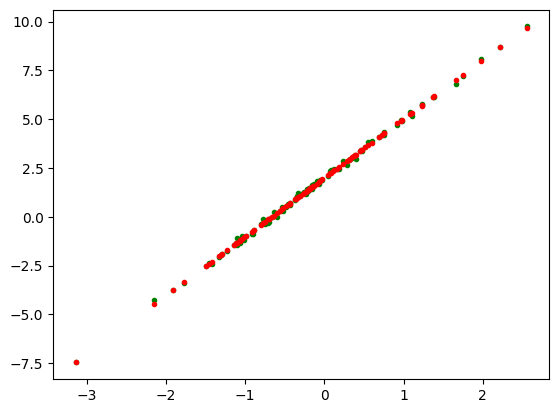

In [68]:
# Task: Linear Regression from scratch
x = torch.randn(100, 1)
y = 3 * x + 2 + torch.randn(100, 1) * 0.1

learning_rate = 0.01
epochs = 500

# Initialize W (weight) and b (bias) as tensors with random numbers from a normal distribution with requires_grad=True
# To be filled-in by students:
# -----------------
W = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)
# -----------------

# Write the optimization loop with Forward, Loss, Backward, Gradient Descent, Zero-Grad
for epoch in range(epochs):
    # To be filled-in by students:
    # -----------------
    hat_y = W*x+b
    loss = ((y-hat_y).pow(2)).mean()
    loss.backward()
    with torch.no_grad():
        W -= learning_rate*W.grad
        b -= learning_rate*b.grad
        W.grad.zero_()
        b.grad.zero_()  
    # -----------------
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss}")
    
    # -----------------
    # reset



plt.plot(x.numpy(), y.numpy(), 'g.');
plt.plot(x.numpy(), hat_y.detach().numpy(), 'r.');
print(f'W = {W.item()}')
print(f'b = {b.item()}')


---

## Designing Custom Data Pipelines

Standard datasets like MNIST comes with a ready-to-use PyTorch dataset class that provides access to the data: `torchvision.datasets.MNIST`.

However, this is not the case for most dataset, including the ones that you will probably create for your task.
Because of this, you must master the `Dataset` class of pytorch which is a central element.
The `Dataset` defines **what** the data is and how to get them.

* **Documentation:** [Custom Datasets Tutorial](https://pytorch.org/docs/stable/data.html)

In [117]:
import math

class SineDataset(Dataset):
    """
    Subclassing Dataset requires implementing __len__ and __getitem__.
    This allows the DataLoader to index the data efficiently.
    """
    def __init__(self, num_samples=1000):
        # Create a sequence 'x' from 0 to 4*pi.
        # Create 'y' as sin(x) + some Gaussian noise.

        # To be filled-in by students:
        # -----------------
        self.x = torch.linspace(0, 4*torch.pi, num_samples).reshape(num_samples,1)
        self.y = torch.sin(self.x)+torch.rand(num_samples).reshape(num_samples,1)
        self.len = num_samples
        # -----------------

    def __len__(self):
        # Must return the total number of samples

        # To be filled-in by students:
        return self.len

    def __getitem__(self, idx):
        # Must return a single sample (input, label)

        # To be filled-in by students:
        return (self.x[idx], self.y[idx])

# Instantiate the SineDataset
dataset = SineDataset()

print(dataset[0])
print(len(dataset))

(tensor([0.]), tensor([0.8954]))
1000


Another important class is the `DataLoader`. It defines **how** to query the Dataset to get a single batch (batch size, shuffling of the data at each epoch, multiprocessing).

In [118]:
# Task: Instantiate the DataLoader with a batch size of 32 and shuffling.

# To be filled-in by students
# -----------------
train_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)
# -----------------

x, y = next(iter(train_loader))
print(x.size(), y.size())

# Shuffle because need to draw indices at random and then go over shuffled sequence of indices

torch.Size([32, 1]) torch.Size([32, 1])


## Write a Neural Network

In PyTorch, there are two primary ways to define a neural network architecture. Choosing between them depends on whether you prioritize simplicity (`nn.Sequential`) or flexibility (`nn.Module`).

* `nn.Sequential`: This is the easiest and fastest way to build a model. You define a list of layers, and PyTorch automatically handles the data flow from one layer to the next in a linear "stack."
    * __Best for__: Simple, "feed-forward" architectures where each layer has exactly one input and one output.

* `nn.Module`: This is the professional standard for most research and production models. You create a Python class that inherits from nn.Module. You define your layers in the `__init__` method and the logic of the data flow in the `forward` method.
    * __Best for__: Complex architectures, models with branching logic, or when you need to inspect/manipulate data between layers.


### The nn.Sequential Abstraction

In PyTorch, `nn.Sequential` is a container module that allows you to stack layers in a fixed, linear order. It is the simplest way to build a neural network when your data flows directly from one layer to the next without any complex branching, skip-connections, or multiple inputs/outputs.

* **Documentation:** [nn.Sequential](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
* **Documentation:** [Non-linear Activations](https://www.google.com/search?q=https://pytorch.org/docs/stable/nn.html%23non-linear-activations-weighted-sum-non-linearity)

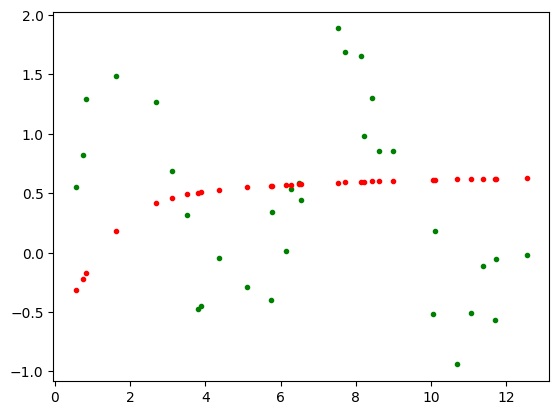

In [ ]:
# Task: Define a simple MLP with two hidden layer (1 -> 64 -> 64 -> 1) with a Tanh activation function using nn.Sequential

# To be filled-in by students
# -----------------
# model : lin_layer = nn.Linear(10, 5, bias = True|False) # 10 neurons to 5 neurons
# lin_layer(x) = Wx+b
model = nn.Sequential(
    nn.Linear(1, 64), nn.Tanh(), nn.Linear(64, 1), nn.Tanh()
)
# -----------------

hat_y = model(x) # doing a forward pass equivalent to a nn.Module.forward
plt.plot(x.numpy(), y.numpy(), 'g.');
plt.plot(x.numpy(), hat_y.detach().numpy(), 'r.');

### The `nn.Module` Abstraction

Every neural network in PyTorch must inherit from `nn.Module`. This class tracks all parameters (weights/biases) defined within it. We usually define layers in `__init__` and the data flow in `forward`.

* **Documentation:** [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)


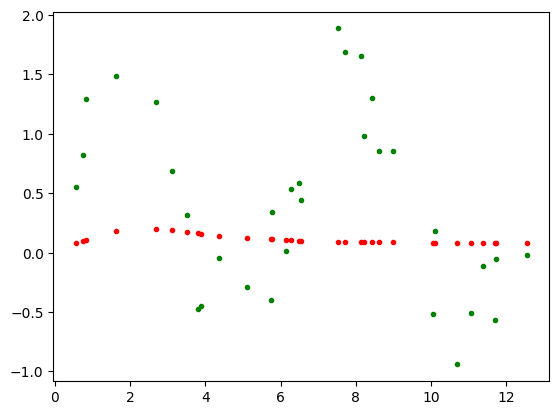

In [156]:
import torch.nn.functional as F


class RegressionMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super(RegressionMLP, self).__init__()
        # We create the layers corresponding to the simple MLP with two hidden layers (1 -> 64 -> 64 -> 1) with a Tanh activation function

        # To be filled-in by students
        # -----------------
        self.lin1 = nn.Linear(1, hidden_dim) # First dim must match the size of the input
        self.lin2 = nn.Linear(hidden_dim, 1) # Last dim must match the size fo the output
        # -----------------


    def forward(self, x):
        # Logic for passing input through the layers

        # To be filled-in by students
        # -----------------
        # option 1 Does not work
        # hat_y = nn.Tanh(self.lin2(nn.Tanh(self.lin1(x))))
        # corrected
        self.tanh = nn.Tanh()
        #hat_y = self.tanh(self.lin2(self.tanh(self.lin1(x))))        
        
        # option 2 deprecated
        #hat_y = F.tanh(self.lin2(F.tanh(self.lin1(x))))
    
        # option 3 - the best
        hat_y = self.lin2(torch.tanh(self.lin1(x)))
        
        # -----------------
        return hat_y

model = RegressionMLP().to(device)
hat_y = model(x.to(device))
plt.plot(x.cpu().numpy(), y.cpu().numpy(), 'g.');
plt.plot(x.cpu().numpy(), hat_y.detach().cpu().numpy(), 'r.');

---

## 5. The Optimization Loop

Training a model follows a strict 5-step choreography:
* Step 1: Clear previous gradients
* Step 2: Prediction (Forward pass)
* Step 3: Compute Loss
* Step 4: Backpropagation (Backward pass)
* Step 5: Update weights
        
Missing one step (especially `zero_grad()`) will lead to silent bugs where gradients accumulate across iterations.

We use the package `nn` to define the loss (MSE, BCE, ...).
* **Documentation:** [Loss Functions](https://www.google.com/search?q=https://pytorch.org/docs/stable/nn.html%23loss-functions)

We use the package `torch.optim` to handle weight updates (SGD, Momentum, Adam, ...).
* **Documentation:** [Optimizers](https://pytorch.org/docs/stable/optim.html)

In [157]:
# Task: Initialize MSE loss and the Adam optimizer (learning rate 0.005)

# To be filled-in by students
# -----------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.named_parameters(), lr=0.005)
# -----------------

model.to(device)
history = []

for epoch in range(epochs):
    model.train() # Set model to training mode
    epoch_loss = 0

    for batch_x, batch_y in train_loader:
        
        # To be filled-in by students:
        # -----------------
        # Step 0: Send data to GPU
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Step 1: Clear previous gradients
        optimizer.zero_grad()
        
        # Step 2: Prediction (Forward pass)
        batch_y_hat = model.forward(batch_x)
        # same than
        # batch_y_hat = model(batch_x)
        
        # Step 3: Compute Loss
        loss = criterion(batch_y, batch_y_hat)
        
        # Step 4: Backpropagation (Backward pass)
        loss.backward()
        
        # Step 5: Update weights
        optimizer.step()
        
        # -----------------

        epoch_loss += loss.item()

    history.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Mean Squared Error = {history[-1]:.5f}")

Epoch 20: Mean Squared Error = 0.42336
Epoch 40: Mean Squared Error = 0.26879
Epoch 60: Mean Squared Error = 0.20278
Epoch 80: Mean Squared Error = 0.17946
Epoch 100: Mean Squared Error = 0.17626
Epoch 120: Mean Squared Error = 0.16842
Epoch 140: Mean Squared Error = 0.15542
Epoch 160: Mean Squared Error = 0.15646
Epoch 180: Mean Squared Error = 0.14919
Epoch 200: Mean Squared Error = 0.15370
Epoch 220: Mean Squared Error = 0.14660
Epoch 240: Mean Squared Error = 0.15477
Epoch 260: Mean Squared Error = 0.13286
Epoch 280: Mean Squared Error = 0.13861
Epoch 300: Mean Squared Error = 0.13338
Epoch 320: Mean Squared Error = 0.13805
Epoch 340: Mean Squared Error = 0.12759
Epoch 360: Mean Squared Error = 0.12195
Epoch 380: Mean Squared Error = 0.12214
Epoch 400: Mean Squared Error = 0.11489
Epoch 420: Mean Squared Error = 0.11447
Epoch 440: Mean Squared Error = 0.11242
Epoch 460: Mean Squared Error = 0.11298
Epoch 480: Mean Squared Error = 0.11064
Epoch 500: Mean Squared Error = 0.10957


---

## 6. Evaluating Performance

After training, we must visualize the **Loss Curve** to check for convergence and the **Model Fit** to see if our MLP actually learned the sine function.

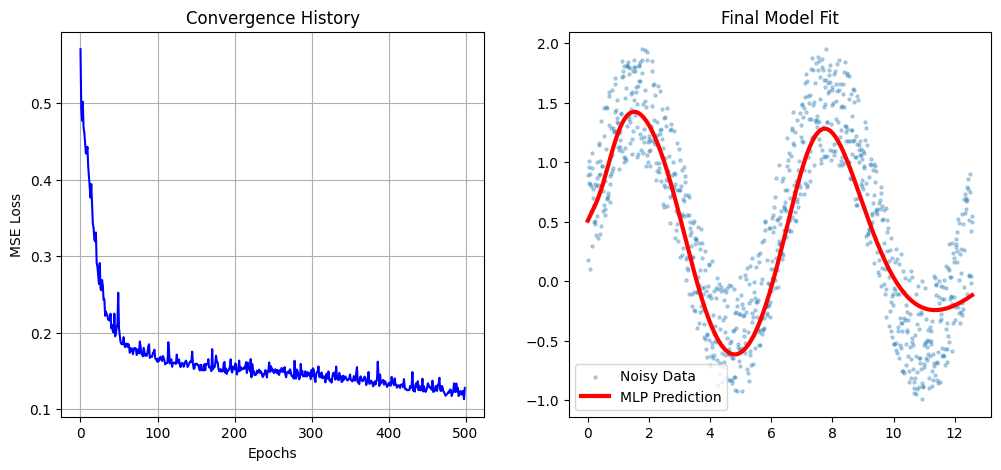

In [152]:
plt.figure(figsize=(12, 5))

# Plot 1: Learning Curve
plt.subplot(1, 2, 1)
plt.plot(history, color='blue', label='Train Loss')
plt.title("Convergence History")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True)

# Plot 2: Inference Comparison
plt.subplot(1, 2, 2)
model.eval() # Set model to evaluation mode (disables dropout/batchnorm if used)
with torch.no_grad(): # Disable gradient tracking for faster inference
    test_x = torch.linspace(0, 4 * np.pi, 200).view(-1, 1).to(device)
    test_y = model(test_x)

plt.scatter(dataset.x.cpu(), dataset.y.cpu(), s=5, alpha=0.3, label="Noisy Data")
plt.plot(test_x.cpu(), test_y.cpu(), color='red', lw=3, label="MLP Prediction")
plt.title("Final Model Fit")
plt.legend()
plt.show()

# Next steps:

* Try changing the `hidden_dim` from 64 to 4. Does the model still fit the curve?
* Swap `nn.Tanh()` for `nn.ReLU()` or `nn.Sigmoid()`. How does the loss curve change?
* Add a second `Dataset` for **Validation** and plot both training and validation loss.

### Create a Wrapper Class

In [249]:
import torch.nn.functional as F

class RegressionMLP(nn.Module):
    def __init__(self, hidden_dim=64, activation_f=nn.Tanh()):
        super(RegressionMLP, self).__init__()
        # We create the layers corresponding to the simple MLP with two hidden layers (1 -> 64 -> 64 -> 1) with a Tanh activation function

        # To be filled-in by students
        # -----------------
        self.lin1 = nn.Linear(1, hidden_dim) # First dim must match the size of the input
        self.lin2 = nn.Linear(hidden_dim, 1) # Last dim must match the size fo the output
        self.activation = activation_f
        self.criterion = nn.MSELoss()
        # -----------------

    def forward(self, x):
        # Logic for passing input through the layers

        # To be filled-in by students
        # -----------------
        hat_y = self.lin2(self.activation(self.lin1(x)))
        # -----------------
        return hat_y
    
    def fit(self, train_loader, criterion=nn.MSELoss(), lr=0.005):
        # Task: Initialize MSE loss and the Adam optimizer (learning rate 0.005)
        # To be filled-in by students
        # -----------------
        optimizer = optim.Adam(model.named_parameters(), lr=lr)
        # -----------------
        self.to(device)
        self.criterion = criterion
        self.history = []
        epochs = 500
        for epoch in range(epochs):
            model.train() # Set model to training mode
            epoch_loss = 0
            for batch_x, batch_y in train_loader:
                # -----------------
                # Step 0: Send data to GPU
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                
                # Step 1: Clear previous gradients
                optimizer.zero_grad()
                
                # Step 2: Prediction (Forward pass)
                batch_y_hat = self.forward(batch_x)
                
                # Step 3: Compute Loss
                loss = criterion(batch_y, batch_y_hat)
                
                # Step 4: Backpropagation (Backward pass)
                loss.backward()
                
                # Step 5: Update weights
                optimizer.step()
                # ----------------
                epoch_loss += loss.item()

            self.history.append(epoch_loss / len(train_loader))
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}: Mean Squared Error = {self.history[-1]:.5f}")
        print(f"Final Epoch Loss: {self.history[-1]}")
    
    def plot_performance(self, dataset):
        plt.figure(figsize=(12, 5))

        # Plot 1: Learning Curve
        plt.subplot(1, 2, 1)
        plt.plot(self.history, color='blue', label='Train Loss')
        plt.title("Convergence History")
        plt.xlabel("Epochs")
        plt.ylabel("MSE Loss")
        plt.grid(True)

        # Plot 2: Inference Comparison
        plt.subplot(1, 2, 2)
        self.eval() # Set model to evaluation mode (disables dropout/batchnorm if used)
        with torch.no_grad(): # Disable gradient tracking for faster inference
            test_x = torch.linspace(0, 4 * np.pi, 200).view(-1, 1).to(device)
            test_y = self(test_x)
            y_mps = dataset.y.to(device)
            y_hat = self(y_mps)

        plt.scatter(dataset.x.cpu(), dataset.y.cpu(), s=5, alpha=0.3, label="Noisy Data")
        plt.plot(test_x.cpu(), test_y.cpu(), color='red', lw=3, label="MLP Prediction")
        plt.title("Final Model Fit")
        plt.legend()
        plt.show()
        loss = self.criterion(y_hat, y_mps)
        print(f"Loss for the dataset is {loss}")

In [250]:
dataset_validation = SineDataset()
train_loader_validation = DataLoader(dataset=dataset_validation, batch_size=32, shuffle=True)

### Dimension froml 64 to 4

Epoch 100: Mean Squared Error = 0.16697
Epoch 200: Mean Squared Error = 0.14663
Epoch 300: Mean Squared Error = 0.14302
Epoch 400: Mean Squared Error = 0.13247
Epoch 500: Mean Squared Error = 0.12274
Final Epoch Loss: 0.12273999070748687


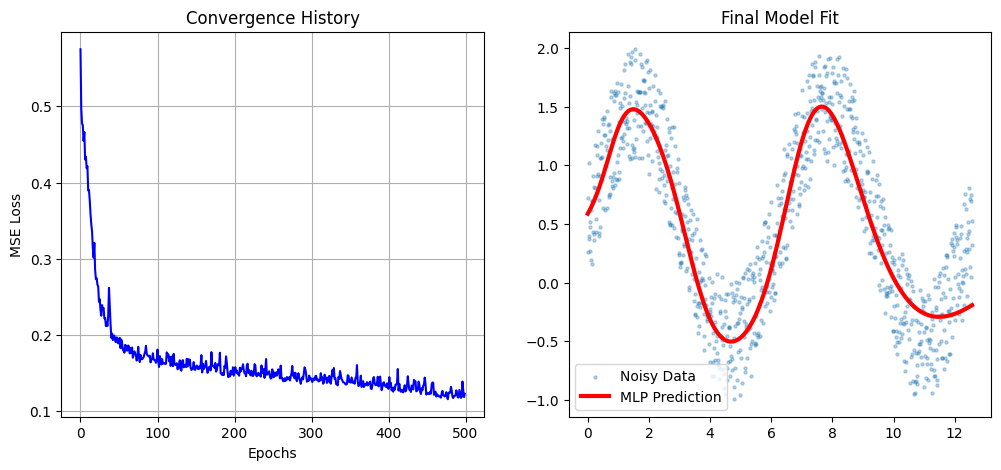

Loss for the dataset is 0.32565540075302124


In [251]:
# Normal size: 64

model = RegressionMLP(hidden_dim=64)
model.fit(train_loader)
model.plot_performance(dataset_validation)

Epoch 100: Mean Squared Error = 0.43430
Epoch 200: Mean Squared Error = 0.44793
Epoch 300: Mean Squared Error = 0.44268
Epoch 400: Mean Squared Error = 0.40890
Epoch 500: Mean Squared Error = 0.35692
Final Epoch Loss: 0.35692034335806966


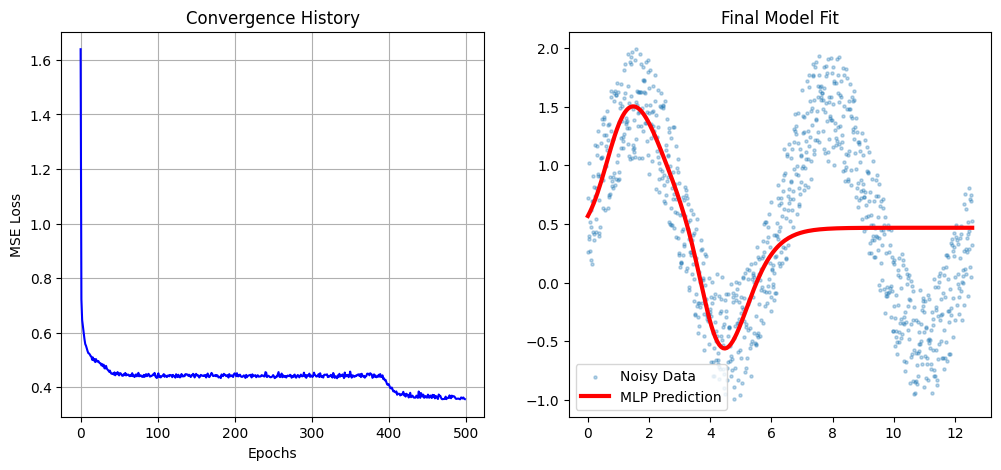

Loss for the dataset is 0.3231092095375061


In [ ]:
model = RegressionMLP(hidden_dim=4)
model.fit(train_loader)
model.plot_performance(dataset_validation)

Epoch 100: Mean Squared Error = 0.43991
Epoch 200: Mean Squared Error = 0.43073
Epoch 300: Mean Squared Error = 0.39873
Epoch 400: Mean Squared Error = 0.38832
Epoch 500: Mean Squared Error = 0.38276
Final Epoch Loss: 0.38275836408138275


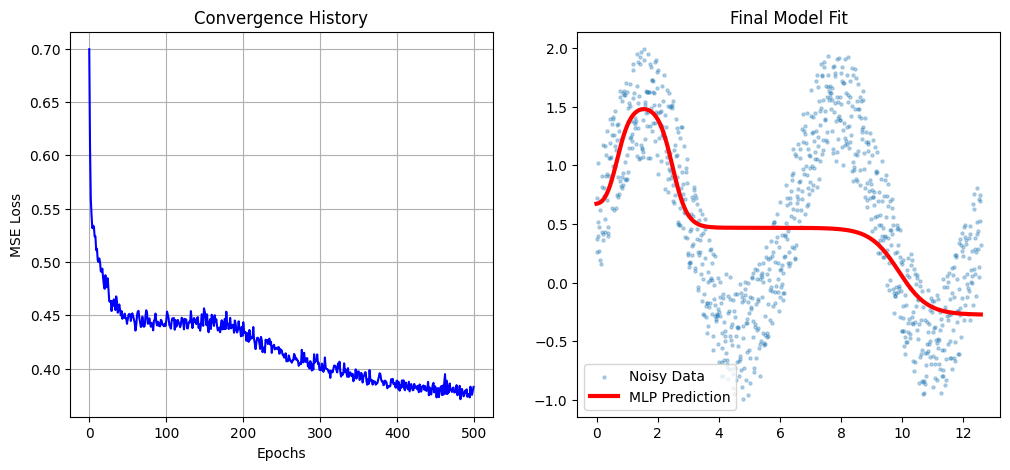

Loss for the dataset is 0.4732958674430847


In [253]:
model = RegressionMLP(hidden_dim=4)
model.fit(train_loader)
model.plot_performance(dataset_validation)

### ReLU

Epoch 100: Mean Squared Error = 0.19068
Epoch 200: Mean Squared Error = 0.17654
Epoch 300: Mean Squared Error = 0.10961
Epoch 400: Mean Squared Error = 0.10176
Epoch 500: Mean Squared Error = 0.09500
Final Epoch Loss: 0.09500354994088411


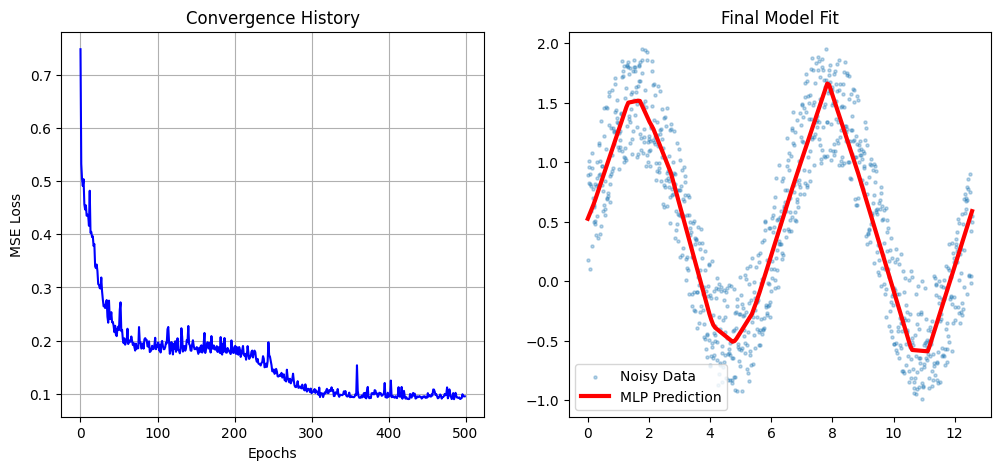

Loss for the dataset is 0.22274817526340485


In [254]:
model = RegressionMLP(hidden_dim=64, activation_f=nn.ReLU())
model.fit(train_loader)
model.plot_performance(dataset)

Epoch 100: Mean Squared Error = 0.52097
Epoch 200: Mean Squared Error = 0.51438
Epoch 300: Mean Squared Error = 0.52337
Epoch 400: Mean Squared Error = 0.52122
Epoch 500: Mean Squared Error = 0.51711
Final Epoch Loss: 0.5171093018725514


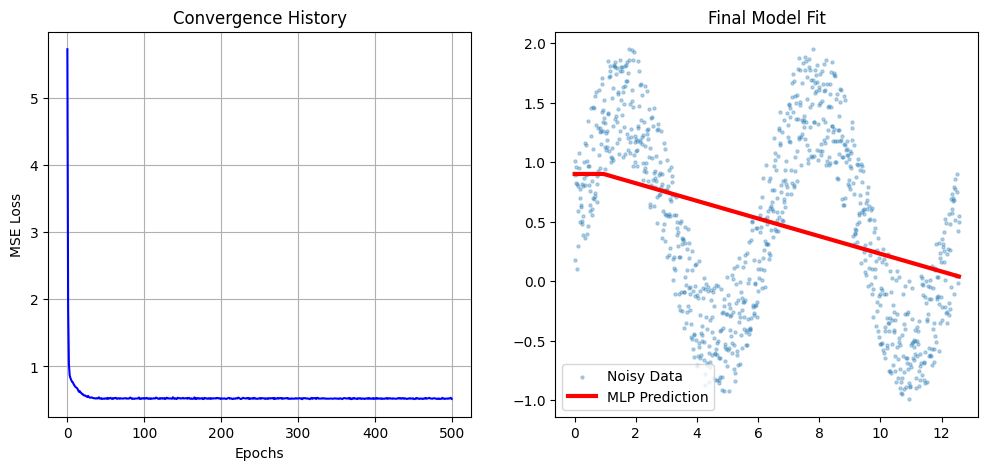

Loss for the dataset is 0.6763181090354919


In [255]:
model = RegressionMLP(hidden_dim=4, activation_f=nn.ReLU())
model.fit(train_loader)
model.plot_performance(dataset)

### Sigmoid

Epoch 100: Mean Squared Error = 0.22206
Epoch 200: Mean Squared Error = 0.17069
Epoch 300: Mean Squared Error = 0.15486
Epoch 400: Mean Squared Error = 0.14613
Epoch 500: Mean Squared Error = 0.13889
Final Epoch Loss: 0.13888773997314274


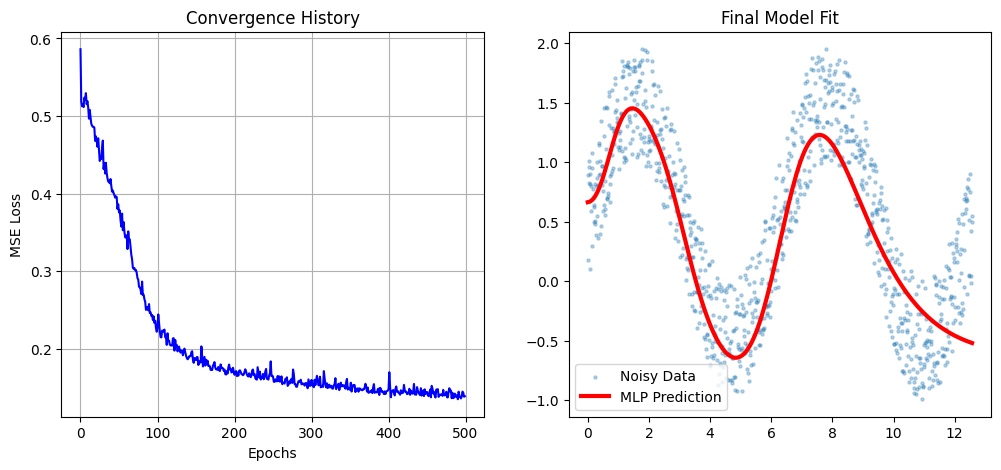

Loss for the dataset is 0.5368027091026306


In [256]:
model = RegressionMLP(hidden_dim=64, activation_f=nn.Sigmoid())
model.fit(train_loader)
model.plot_performance(dataset)

Epoch 100: Mean Squared Error = 0.44650
Epoch 200: Mean Squared Error = 0.44042
Epoch 300: Mean Squared Error = 0.43951
Epoch 400: Mean Squared Error = 0.43647
Epoch 500: Mean Squared Error = 0.38811
Final Epoch Loss: 0.3881136900745332


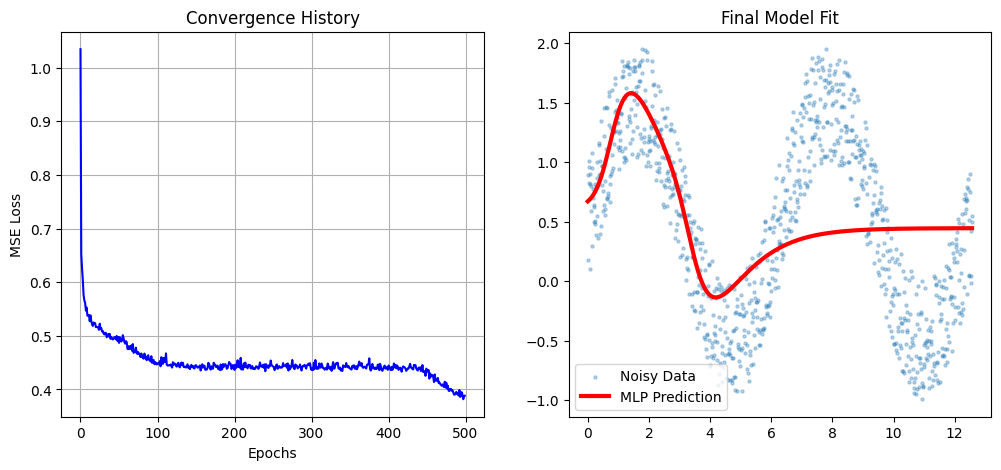

Loss for the dataset is 0.4923102855682373


In [257]:
model = RegressionMLP(hidden_dim=4, activation_f=nn.Sigmoid())
model.fit(train_loader)
model.plot_performance(dataset)